## YOLO in a Nutshell

YOLO (**You Only Look Once**) is an object detection approach that looks at an image in a single forward pass and predicts both **what** objects are present and **where** they are located. This makes it fast and practical for real-time computer vision tasks such as image analysis, video processing, and webcam-based detection.

In this notebook, we will build a simple end-to-end YOLO workflow using **OpenCV DNN** and an **ONNX** model. Step by step, we will load the model, run detection on a single image, extend the same pipeline to video and webcam input, and finally explore how confidence and non-max suppression (NMS) thresholds affect the results.

The goal is not only to run YOLO, but also to understand the full detection pipeline clearly enough to explain, modify, and reuse it in your own proects.

### YOLO in context

We use **YOLOv8** in this notebook because it is modern, widely used, and fits the detection pipeline we teach here: ONNX loading, inference, postprocessing, NMS, and visualization.  Newer Ultralytics versions such as **YOLO11** and **YOLO26** show how the family continues to evolve, so this notebook gives a solid foundation before moving to newer models. 

| Version | Year | Why it matters |
|---|---:|---|
| YOLO / YOLOv1 | 2015 paper, 2016 CVPR | Introduced the core single-stage real-time object detection idea.  |
| YOLOv3 | 2018  | A major classic milestone that made YOLO widely adopted in practice.  |
| YOLOv7 | 2022  | A strong real-time detector and an important pre-Ultralytics-modern milestone.  |
| YOLOv8 | 2023 | A practical and accessible Ultralytics generation that is very suitable for teaching and prototyping. |
| YOLO11 | 2024  | A newer Ultralytics generation with improved efficiency and accuracy. |
| YOLO26 | 2026  | A recent Ultralytics family focused on newer end-to-end and edge-oriented ideas.  |



## Setup and installation

Before we run any YOLO code, we first check that the required libraries are available in our notebook environment. In this step, we import **OpenCV** for computer vision tasks and **NumPy** for numerical array operations, then print their versions to confirm that everything is installed correctly.

If OpenCV is not installed yet, we can install it once and then rerun the cell. A successful import and version check means we are ready to continue with the rest of the notebook.


In [1]:
# Setup and installation

# If OpenCV is not installed in your environment, uncomment and run this once:
# !pip install opencv-python

import cv2
import numpy as np

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)


OpenCV version: 4.10.0
NumPy version: 1.26.4


## Set model path and verify file exists

In this step, we define the path to the YOLO model file that will be used later for inference. Since this notebook uses an **ONNX** model, we point `MODEL_PATH` to the file and check whether it exists on disk.

#### What is the ONNX model?

>> The YOLO detector we use in this notebook is saved as an **ONNX** file.

This file contains the trained model in a format that OpenCV can load, making it easy to use the same detector for images, video, and webcam input.


In [3]:
# Set model path and verify file exists

import os

# Adjust this path to where you place your YOLO ONNX file
MODEL_PATH = "models/yolov8n.onnx"

print("Model path:", MODEL_PATH)
print("Exists:", os.path.exists(MODEL_PATH))


Model path: models/yolov8n.onnx
Exists: True


## Step 3: Load YOLO model with OpenCV DNN

Now that the model file exists, we can load it into OpenCV’s **DNN** module. This creates a network object that we will use later to run inference on images, video frames, and webcam input. 

>> A YOLO network is built as a stack of learned layers: early layers detect basic visual patterns such as edges, textures, and shapes; deeper layers combine these patterns into more meaningful object features; and the final detection layers predict bounding boxes, confidence scores, and class probabilities in a single forward pass. 

In this notebook, inspecting the layer list is mainly a quick way to confirm that the model loaded correctly and that the network is ready for the next steps. 


In [5]:
# Load YOLO model with OpenCV DNN

import cv2

MODEL_PATH = "models/yolov8n.onnx"

# Load the ONNX model
net = cv2.dnn.readNetFromONNX(MODEL_PATH)

print("Model loaded successfully!")
print("Network layers:", len(net.getLayerNames()))
print("Available layers:")
for i, name in enumerate(net.getLayerNames()[:10]):  # Show first 10
    print(f"  {i}: {name}")


Model loaded successfully!
Network layers: 248
Available layers:
  0: onnx_node!/model.0/conv/Conv
  1: onnx_node!/model.0/act/Sigmoid
  2: onnx_node!/model.0/act/Mul
  3: onnx_node!/model.1/conv/Conv
  4: onnx_node!/model.1/act/Sigmoid
  5: onnx_node!/model.1/act/Mul
  6: onnx_node!/model.2/cv1/conv/Conv
  7: onnx_node!/model.2/cv1/act/Sigmoid
  8: onnx_node!/model.2/cv1/act/Mul
  9: onnx_node!/model.2/Slice


## Load and display a test image

Before running object detection, we first need an image to work with. In this step, we define the image path, create the `images/` folder if needed, and download a sample image automatically when no local image is available.

Next, we load the image with OpenCV and display it inside the notebook. Since OpenCV reads images in **BGR** format while Matplotlib displays them in **RGB**, we convert the image before plotting so that the colors appear correctly.

This step helps us confirm that the image was loaded successfully and gives us a clear visual starting point before preprocessing and detection.


Image shape: (859, 1480, 3)


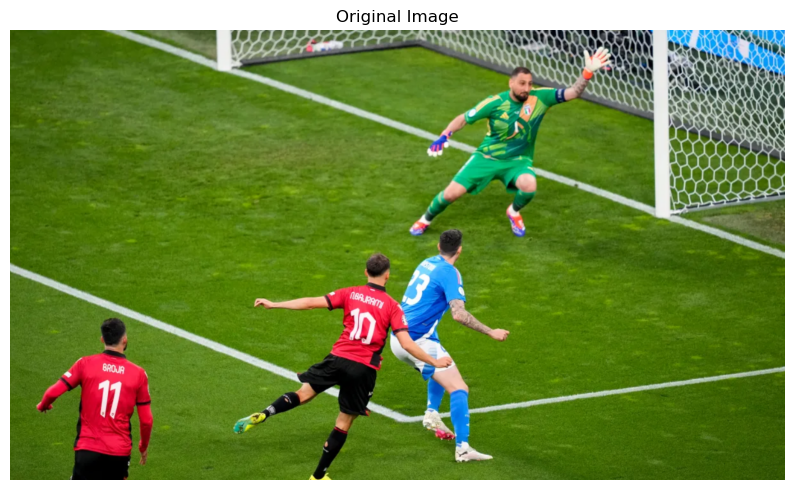

In [7]:
# Load and display test image

import matplotlib.pyplot as plt

# Put a test image in images/ folder, or create one
IMAGE_PATH = "images/image.png"

# Create images folder and download sample image if needed
import os
import urllib.request

os.makedirs("images", exist_ok=True)

if not os.path.exists(IMAGE_PATH):
    # Download sample image with people/objects (COCO classes)
    sample_url = "https://ultralytics.com/images/bus.jpg"
    print("Downloading sample image...")
    urllib.request.urlretrieve(sample_url, IMAGE_PATH)
    print("Downloaded!")

# Load image
image = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert for matplotlib

print("Image shape:", image.shape)
plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.axis('off')
plt.title("Original Image")
plt.show()


## Preprocess the image for YOLO

Before the image can be passed into the YOLO network, it must be converted into the format expected by the model. In this step, we create a preprocessing function that resizes the image to the model input size, scales pixel values to the range `[0, 1]`, and converts it into a **blob** that OpenCV DNN can use for inference.

>> A **blob** is simply a structured numerical representation of the image prepared for the neural network. It organizes the image data into the shape the model expects, usually including the batch size, number of color channels, and spatial dimensions.

We also keep the original image width and height. These original dimensions are important because the model makes predictions on the resized input, but later we need to map the detected bounding boxes back to the coordinates of the original image.

After running the function, we print the blob shape and the original image size to confirm that preprocessing worked as expected. This gives us a clean bridge between loading the image and running the model in the next step.


In [9]:
# Preprocessing function for YOLOv8 ONNX

def preprocess_image(image, input_size=(640, 640)):
    """
    Preprocess image for YOLOv8 ONNX inference
    """
    # Get original dimensions
    h, w = image.shape[:2]
    
    # Create blob (handles resize + normalization)
    blob = cv2.dnn.blobFromImage(
        image, 
        scalefactor=1/255.0,  # Normalize to [0,1]
        size=input_size,      # Resize to model input size
        swapRB=True,          # BGR -> RGB
        crop=False
    )
    
    return blob, w, h

# Test on your image
blob, orig_w, orig_h = preprocess_image(image)

print("Blob shape:", blob.shape)  # Should be (1, 3, 640, 640)
print("Original dimensions:", orig_w, orig_h)


Blob shape: (1, 3, 640, 640)
Original dimensions: 1480 859


## Run the forward pass

Now that the image has been preprocessed into a blob, we can pass it through the YOLO network. This step is called the **forward pass**, which means the input moves through all the learned layers of the model to produce raw detection predictions.

>> At this stage, the output is not yet a final list of labeled boxes. Instead, it contains the model’s raw numerical predictions, which typically encode bounding box information, confidence values, and class-related scores for many possible detections.

We print the output shape and value range to better understand what the network returns. This is a useful inspection step because it helps us confirm that inference worked correctly before we move on to decoding and filtering the detections.


In [11]:
# Run forward pass through YOLO model

# Set input and run inference
net.setInput(blob)
outputs = net.forward()

print("Forward pass complete!")
print("Output shape(s):")
if isinstance(outputs, list):
    for i, out in enumerate(outputs):
        print(f"  Output {i}: {out.shape}")
else:
    print(f"  Single output: {outputs.shape}")

print("Raw output range:", outputs.min(), "to", outputs.max())


Forward pass complete!
Output shape(s):
  Single output: (1, 84, 8400)
Raw output range: 2.8228821e-14 to 0.9960543


## Postprocess raw YOLO outputs

After the forward pass, the model returns **raw predictions**, not final detections yet. In this step, we transform those predictions into something easier to interpret: bounding boxes, confidence scores, and predicted class IDs.

For YOLOv8 ONNX, each prediction contains box information plus class scores, so we first separate these parts and then keep the class with the highest score for each candidate detection. Next, we filter out weak predictions using a **confidence threshold**, which helps remove many low-quality detections. 

>> The bounding boxes are initially represented in the form `(center_x, center_y, width, height)`. Since boxes are easier to draw and analyze using corner coordinates, we convert them into `(x1, y1, x2, y2)` and then scale them back to the size of the original image. 

At the end of this step, we have a cleaner list of candidate detections. These results are much more meaningful than the raw network output, and they prepare us for the next step, where we will remove overlapping boxes using non-max suppression.


In [14]:
# Postprocess YOLOv8 outputs → boxes, scores, classes

def postprocess_yolov8(outputs, conf_threshold=0.25, img_width=None, img_height=None):
    """
    Convert YOLOv8 raw outputs to boxes/confidences/classes
    """
    # YOLOv8 ONNX output: (1, 84, 8400) = [cx,cy,w,h, 80 class probs]
    predictions = outputs[0].transpose(1, 0)  # (8400, 84)
    
    # Extract boxes (cx,cy,w,h) and confidences
    boxes = predictions[:, :4]      # (8400, 4)
    class_scores = predictions[:, 4:]  # (8400, 80)
    
    # Max class score per detection
    confs, class_ids = np.max(class_scores, axis=1), np.argmax(class_scores, axis=1)
    
    # Filter by confidence threshold
    mask = confs > conf_threshold
    boxes = boxes[mask]
    confs = confs[mask]
    class_ids = class_ids[mask]
    
    # Convert center_x,center_y,width,height to x1,y1,x2,y2
    x_center, y_center, width, height = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = x_center - 0.5 * width
    y1 = y_center - 0.5 * height
    x2 = x_center + 0.5 * width
    y2 = y_center + 0.5 * height
    
    # Scale back to original image size
    if img_width and img_height:
        x1, y1, x2, y2 = x1 * img_width, y1 * img_height, x2 * img_width, y2 * img_height
    
    boxes = np.stack([x1, y1, x2, y2], axis=1)
    
    print(f"Filtered {len(boxes)} detections above {conf_threshold}")
    return boxes, confs, class_ids

# Test on our outputs
boxes, confs, class_ids = postprocess_yolov8(outputs, conf_threshold=0.25, img_width=orig_w, img_height=orig_h)

print("Sample detections:")
for i in range(min(5, len(boxes))):
    print(f"  Box {i}: {boxes[i]}, conf: {confs[i]:.3f}, class: {class_ids[i]}")


Filtered 42 detections above 0.25
Sample detections:
  Box 0: [1090.7334     36.684338 1148.992      84.04672 ], conf: 0.420, class: 38
  Box 1: [1089.5063     37.06192  1148.4247     86.371086], conf: 0.514, class: 38
  Box 2: [ 758.5087    46.50384 1130.6812   398.4802 ], conf: 0.855, class: 0
  Box 3: [ 760.3725     46.345493 1136.2521    398.9747  ], conf: 0.899, class: 0
  Box 4: [ 759.39014   47.0518  1141.2582   399.4662 ], conf: 0.897, class: 0


## Apply Non-Max Suppression (NMS)

At this stage, the model may still produce several boxes for the same object. This happens because nearby predictions can all have high confidence and overlap heavily, even though they refer to a single real object. 

>> **Non-Max Suppression (NMS)** helps solve this problem by keeping the strongest box and removing weaker overlapping boxes.

In practice, we use the confidence threshold to decide which detections are worth considering, and the NMS threshold to decide when two boxes overlap too much and one of them should be discarded. 

After applying NMS, we are left with a smaller and cleaner set of final detections. These are the boxes we will use in the next step when drawing results on the image.


In [19]:
# Apply Non-Max Suppression (NMS)

CONF_THRESHOLD = 0.25
NMS_THRESHOLD = 0.4

# Apply NMS
indices = cv2.dnn.NMSBoxes(
    boxes.astype(np.float32).tolist(), 
    confs.tolist(), 
    CONF_THRESHOLD, 
    NMS_THRESHOLD
)

print(f"After NMS: {len(indices)} final detections")

if len(indices) > 0:
    indices = indices.flatten()
    print("Kept indices:", indices[:5])
else:
    print("No detections after NMS")


After NMS: 5 final detections
Kept indices: [32  6 15 17  1]


## Build the `draw_boxes` function

After we obtain the final detections, the next step is to visualize them on the image. In this function, we take the selected boxes from NMS and draw a rectangle around each detected object, together with a text label showing the predicted class and confidence score. 

>> This function is an important part of the detection pipeline because it turns numerical results into something we can inspect visually. 

By writing this as a reusable function, we can later apply the same drawing logic not only to one image, but also to video frames and webcam input. 


In [23]:
# Complete draw_boxes function 

def draw_boxes(image, boxes, confs, class_ids, indices):
    """
    Draw bounding boxes and labels on image
    """
    annotated = image.copy()
    
    if len(indices) > 0:
        for i in indices:
            # Extract box
            box = boxes[i]
            x1, y1, x2, y2 = map(int, box)
            
            # Draw rectangle (green box)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Get label
            conf = confs[i]
            class_id = class_ids[i]
            label = f"{COCO_CLASSES[class_id]}: {conf:.2f}"
            
            # Draw label background
            (w_label, h_label), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(annotated, (x1, y1 - h_label - 10), (x1 + w_label, y1), (0, 255, 0), -1)
            
            # Draw label text
            cv2.putText(annotated, label, (x1, y1 - 5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    return annotated


## Add class names and run the complete image pipeline

To turn class IDs into readable labels, we define the 80 standard **COCO** class names used by many YOLO models. This allows us to display human-friendly names such as `person`, `car`, or `bus` instead of only numeric class indices. 

Once the class list is available, we can connect all previous steps into one complete detection pipeline: preprocess the image, run the forward pass, postprocess the predictions, apply non-max suppression, and draw the final labeled boxes. 

This is the first full end-to-end result in the notebook. It brings together everything we built so far and shows how the individual pieces combine into a practical object detection workflow on a single image.

Loaded 80 COCO classes
Sample classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane'] ... ['vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
Filtered 42 detections above 0.25


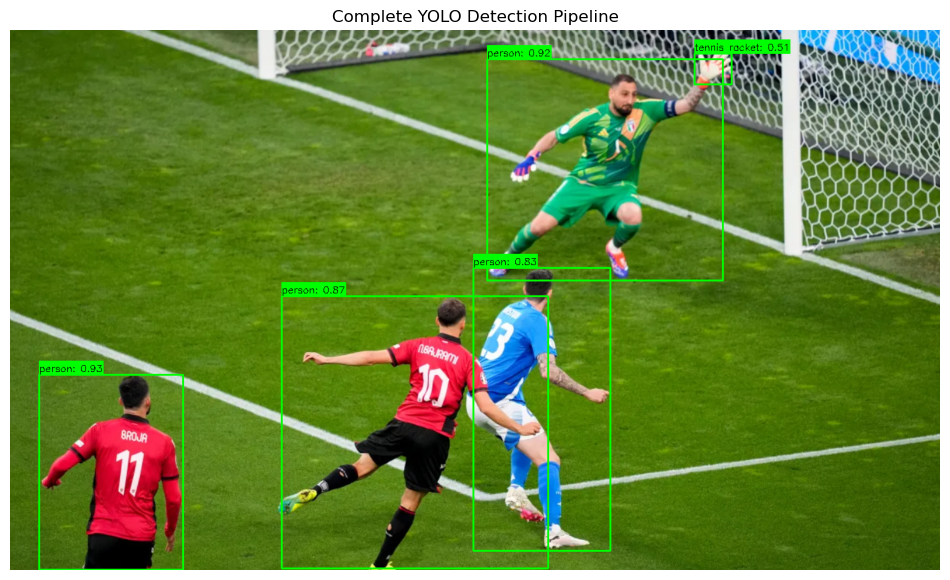

Detected 5 objects


In [25]:

# Hardcoded COCO 80 class names (YOLOv8 standard)
COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 
    'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 
    'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 
    'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 
    'toothbrush'
]

print(f"Loaded {len(COCO_CLASSES)} COCO classes")
print("Sample classes:", COCO_CLASSES[:5], "...", COCO_CLASSES[-5:])

# Full pipeline
blob, orig_w, orig_h = preprocess_image(image)
net.setInput(blob)
outputs = net.forward()
boxes, confs, class_ids = postprocess_yolov8(outputs, 0.25, orig_w, orig_h)
indices = cv2.dnn.NMSBoxes(
    boxes.astype(np.float32).tolist(), 
    confs.tolist(), 
    0.25, 
    0.4
)

# Draw and display
annotated_image = draw_boxes(image, boxes, confs, class_ids, indices)
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Complete YOLO Detection Pipeline")
plt.show()

print(f"Detected {len(indices) if len(indices)>0 else 0} objects")


## Complete single-image detection function

>> So far, we built the YOLO image pipeline step by step.
>> In this section, we combine all those steps into one clean reusable function.

- Load the image from disk and check that it was read correctly.
- Preprocess the image into a blob that matches the model input format.
- Run the forward pass through the YOLO network.
- Convert the raw model output into bounding boxes, confidence scores, and class IDs.
- Apply Non-Max Suppression (NMS) to remove overlapping duplicate detections.
- Draw the final labeled boxes on the image.
- Return the annotated image so it can be displayed or reused later.

>> This shows how the full detection pipeline can be packaged into a single function without losing the logic of the earlier steps.

>> It also prepares us to reuse the same structure later for video files and webcam streams.


Filtered 47 detections above 0.25
Detected 5 objects in images/bus.jpg


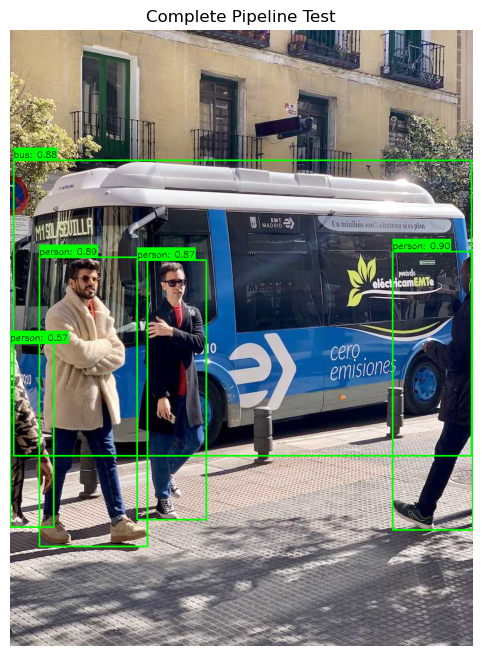

In [31]:
# Step 5: Fixed complete single-image detection function

def detect_single_image(image_path, net, conf_threshold=0.25, nms_threshold=0.4):
    """
    Complete end-to-end detection on single image
    """
    # Load image with error check
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    # Preprocess
    blob, orig_w, orig_h = preprocess_image(image)
    
    # Inference
    net.setInput(blob)
    outputs = net.forward()
    
    # Postprocess
    boxes, confs, class_ids = postprocess_yolov8(outputs, conf_threshold, orig_w, orig_h)
    indices = cv2.dnn.NMSBoxes(
        boxes.astype(np.float32).tolist(), 
        confs.tolist(), 
        conf_threshold, 
        nms_threshold
    )
    
    # Draw
    annotated = draw_boxes(image, boxes, confs, class_ids, indices)
    
    print(f"Detected {len(indices) if len(indices)>0 else 0} objects in {image_path}")
    return annotated

# Test it
result = detect_single_image("images/bus.jpg", net)  
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Complete Pipeline Test")
plt.show()


## Vdeo detection pipeline

>> After building a complete pipeline for one image, the next natural step is to apply the same idea to video.
>> A video is simply a sequence of frames, so we can run our detector on each frame one by one.

- `detect_frame(...)` handles detection on a single video frame.
- It reuses the same pipeline we already built for images: preprocessing, inference, postprocessing, NMS, and drawing.
- `detect_video(...)` opens a video file and reads it frame by frame.
- For each frame, it calls `detect_frame(...)` and produces an annotated result.
- If an output path is provided, the processed frames are written into a new video file.
- The code also measures total processing time and estimates the average FPS to give a simple idea of performance.
- The `max_frames` option is useful for testing because it lets us run on only a small part of the video first.


>> The same YOLO pipeline can be reused for continuous visual data, which is the foundation for video analytics and real-time applications.


In [34]:
# Video detection pipeline

def detect_frame(frame, net, conf_threshold=0.25, nms_threshold=0.4):
    """
    Detect on a single frame (not file path)
    """
    # Preprocess frame
    blob, orig_w, orig_h = preprocess_image(frame)
    
    # Inference
    net.setInput(blob)
    outputs = net.forward()
    
    # Postprocess
    boxes, confs, class_ids = postprocess_yolov8(outputs, conf_threshold, orig_w, orig_h)
    indices = cv2.dnn.NMSBoxes(
        boxes.astype(np.float32).tolist(), 
        confs.tolist(), 
        conf_threshold, 
        nms_threshold
    )
    
    # Draw
    return draw_boxes(frame, boxes, confs, class_ids, indices)

def detect_video(video_path, net, conf_threshold=0.25, nms_threshold=0.4, 
                 output_path=None, max_frames=None):
    """
    Run YOLO detection on video file
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Output video writer
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    else:
        out = None
    
    frame_count = 0
    total_time = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_count += 1
        
        # Detect on frame
        start_time = cv2.getTickCount()
        annotated = detect_frame(frame, net, conf_threshold, nms_threshold)
        end_time = cv2.getTickCount()
        inference_time = (end_time - start_time) / cv2.getTickFrequency()
        total_time += inference_time
        
        # Write output
        if out:
            out.write(annotated)
        
        # Limit for testing
        if max_frames and frame_count >= max_frames:
            break
    
    cap.release()
    if out:
        out.release()
    
    avg_fps = frame_count / total_time if total_time > 0 else 0
    print(f"Processed {frame_count} frames")
    print(f"Average FPS: {avg_fps:.1f}")
    return avg_fps

# Test
fps = detect_video("videos/traffic.mp4", net, max_frames=50, output_path="output.mp4")


Filtered 155 detections above 0.25
Filtered 144 detections above 0.25
Filtered 146 detections above 0.25
Filtered 147 detections above 0.25
Filtered 148 detections above 0.25
Filtered 141 detections above 0.25
Filtered 152 detections above 0.25
Filtered 147 detections above 0.25
Filtered 150 detections above 0.25
Filtered 148 detections above 0.25
Filtered 139 detections above 0.25
Filtered 141 detections above 0.25
Filtered 133 detections above 0.25
Filtered 132 detections above 0.25
Filtered 124 detections above 0.25
Filtered 141 detections above 0.25
Filtered 138 detections above 0.25
Filtered 136 detections above 0.25
Filtered 145 detections above 0.25
Filtered 152 detections above 0.25
Filtered 144 detections above 0.25
Filtered 151 detections above 0.25
Filtered 141 detections above 0.25
Filtered 150 detections above 0.25
Filtered 128 detections above 0.25
Filtered 136 detections above 0.25
Filtered 153 detections above 0.25
Filtered 149 detections above 0.25
Filtered 144 detecti

## Video detection with live display

>> In the previous step, we processed a video file and optionally saved the annotated result.
>> In this step, we go one step further and display the processed frames live in a window as the video is being analyzed.

- Open the video file with `cv2.VideoCapture(...)`.
- Read frames one by one in a loop.
- Run the YOLO detection pipeline on each frame using `detect_frame(...)`.
- Compute a simple FPS estimate from the frame processing time.
- Draw the FPS value on the displayed frame.
- Show the annotated result in a live OpenCV window.
- Stop the loop either when the video ends, when the frame limit is reached, or when the user presses `q`.



In [41]:
# Video detection with live display

def detect_video_live(video_path, net, conf_threshold=0.25, nms_threshold=0.4, 
                      max_frames=None):
    """
    Video detection with cv2.imshow window (press 'q' to quit)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    
    frame_count = 0
    total_time = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_count += 1
        
        # Detect
        start_time = cv2.getTickCount()
        annotated = detect_frame(frame, net, conf_threshold, nms_threshold)
        end_time = cv2.getTickCount()
        inference_time = (end_time - start_time) / cv2.getTickFrequency()
        total_time += inference_time
        
        # Add FPS text
        fps = 1.0 / inference_time if inference_time > 0 else 0
        cv2.putText(annotated, f"FPS: {fps:.1f}", (10, 30), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        
        # Show frame
        cv2.imshow('YOLO Video Detection (press q to quit)', annotated)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        
        if max_frames and frame_count >= max_frames:
            break
    
    cap.release()
    cv2.destroyAllWindows()
    
    avg_fps = frame_count / total_time if total_time > 0 else 0
    print(f" Processed {frame_count} frames at {avg_fps:.1f} FPS avg")
    return avg_fps

# Run full video with live display
# bus.mp4, traffic.mp4, goal.mp4
fps = detect_video_live("videos/bus.mp4", net)


Filtered 91 detections above 0.25
Filtered 91 detections above 0.25
Filtered 91 detections above 0.25
Filtered 91 detections above 0.25
Filtered 91 detections above 0.25
Filtered 89 detections above 0.25
Filtered 88 detections above 0.25
Filtered 93 detections above 0.25
Filtered 94 detections above 0.25
Filtered 93 detections above 0.25
Filtered 94 detections above 0.25
Filtered 102 detections above 0.25
Filtered 101 detections above 0.25
Filtered 98 detections above 0.25
Filtered 98 detections above 0.25
Filtered 107 detections above 0.25
Filtered 99 detections above 0.25
Filtered 101 detections above 0.25
Filtered 104 detections above 0.25
Filtered 114 detections above 0.25
Filtered 121 detections above 0.25
Filtered 113 detections above 0.25
Filtered 110 detections above 0.25
Filtered 106 detections above 0.25
Filtered 103 detections above 0.25
Filtered 110 detections above 0.25
Filtered 103 detections above 0.25
Filtered 106 detections above 0.25
Filtered 104 detections above 0.25

## Webcam detection (your own camera)

>> In this step, we move from prerecorded video to a live camera stream.
>> Instead of reading frames from a file, we capture them directly from the webcam and run the same YOLO pipeline in real time.

- Open the webcam using `cv2.VideoCapture(camera_index)`.
- Check whether the selected camera is available before starting the loop.
- Read frames continuously from the camera.
- Reuse the same `detect_frame(...)` function we already built for video.
- Measure processing time for each frame and estimate the current FPS.
- Draw useful overlay information such as FPS and confidence threshold.
- Display the annotated webcam stream in a live OpenCV window.
- Stop the session cleanly when the user presses `q`.


In [44]:
# Webcam detection (your own camera)

def detect_webcam(net, conf_threshold=0.25, nms_threshold=0.4, camera_index=0):
    """
    Real-time webcam detection
    """
    cap = cv2.VideoCapture(camera_index)
    
    if not cap.isOpened():
        print(f"Cannot open camera {camera_index}")
        print("Try camera_index=1 or 2 if you have multiple cameras")
        return
    
    print(f"Webcam opened (index {camera_index})")
    print("Press 'q' to quit, 'c' to change confidence")
    
    frame_count = 0
    total_time = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break
            
        frame_count += 1
        
        # Detect
        start_time = cv2.getTickCount()
        annotated = detect_frame(frame, net, conf_threshold, nms_threshold)
        end_time = cv2.getTickCount()
        inference_time = (end_time - start_time) / cv2.getTickFrequency()
        total_time += inference_time
        
        # FPS overlay
        fps = 1.0 / inference_time if inference_time > 0 else 0
        cv2.putText(annotated, f"FPS: {fps:.1f}", (10, 30), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(annotated, f"Conf: {conf_threshold:.2f}", (10, 60), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        # Show
        cv2.imshow('YOLO Webcam Detection (q=quit)', annotated)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()
    print(f"Webcam session ended ({frame_count} frames)")
    
    return frame_count

# Start webcam detection
detect_webcam(net)


Webcam opened (index 0)
Press 'q' to quit, 'c' to change confidence
Filtered 0 detections above 0.25
Filtered 15 detections above 0.25
Filtered 10 detections above 0.25
Filtered 12 detections above 0.25
Filtered 12 detections above 0.25
Filtered 13 detections above 0.25
Filtered 11 detections above 0.25
Filtered 10 detections above 0.25
Filtered 11 detections above 0.25
Filtered 9 detections above 0.25
Filtered 12 detections above 0.25
Filtered 10 detections above 0.25
Filtered 10 detections above 0.25
Filtered 8 detections above 0.25
Filtered 8 detections above 0.25
Filtered 10 detections above 0.25
Filtered 8 detections above 0.25
Filtered 12 detections above 0.25
Filtered 16 detections above 0.25
Filtered 20 detections above 0.25
Filtered 14 detections above 0.25
Filtered 13 detections above 0.25
Filtered 11 detections above 0.25
Filtered 11 detections above 0.25
Filtered 17 detections above 0.25
Filtered 25 detections above 0.25
Filtered 19 detections above 0.25
Filtered 18 detecti

119

## Summary

In this notebook, we built a complete **YOLO object detection pipeline** step by step using **OpenCV DNN** and an **ONNX** model.

We started by:
- Checking that OpenCV and NumPy were installed correctly.
- Setting the model path and verifying that the YOLO ONNX file existed.
- Loading the trained YOLO network into OpenCV.

We then developed the full image detection pipeline:
- Load and display an input image.
- Preprocess the image into a blob.
- Run a forward pass through the network.
- Postprocess the raw outputs into boxes, scores, and class predictions.
- Apply Non-Max Suppression (NMS) to remove overlapping duplicate detections.
- Draw the final labeled boxes on the image.

After that, we generalized the same logic to:
- A reusable single-image detection function.
- Video file processing frame by frame.
- Live video display with FPS monitoring.
- Real-time webcam detection using the same detection pipeline.

>> The key idea is that the same core steps — **preprocess → infer → postprocess → filter → visualize** — can be reused across images, videos, and live camera streams.
